# RailCross model evaluation

## tl;dr

On **crossings the model never saw during training**, the classifier reached **59.3% F1** and **88.8% ROC-AUC** (63.4% / 90.2% on held-out events from training crossings). At the event level it missed only **2.2%** of unseen-crossing closures, with a median detection delay of **90 seconds**.

When the model is allowed to answer **UNKNOWN** inside its tuned uncertainty band (abstaining on 17.2% of unseen-crossing rows), accuracy on decided rows rises to **90.3%**. The reopening-time survival model achieved **1.64 minutes MAE**.

These are **synthetic benchmark results only**. They demonstrate the pipeline and model behavior; they do not establish real-world accuracy.

## Context & Methods

RailCross predicts whether a known railway crossing is currently closed and, when closed, estimates the remaining time until reopening. When the closure probability falls inside a validation-tuned uncertainty band, the model reports UNKNOWN instead of guessing.

### Key Assumptions

- The simulator mirrors public Google Routes-style inputs: traffic-aware duration, static duration, and NORMAL/SLOW/TRAFFIC_JAM segment states.
- It does not reproduce or claim access to Google internal traffic data.
- 14 simulated crossings span busy urban to quiet rural profiles. Three full crossings are held out as an **unseen-crossing test set**; the rest are split chronologically by `event_id` so no closure event straddles train and test.
- Ordinary road congestion, accidents, market days, construction, school zones, signal failures and flooding are simulated as hard negatives so the classifier cannot equate every traffic jam with a railway closure.

In [1]:
from pathlib import Path
import csv
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATASET = ROOT / 'data' / 'synthetic' / 'crossing_observations.csv'
REPORT = ROOT / 'artifacts' / 'model_evaluation.json'
report = json.loads(REPORT.read_text())
report['dataset']

{'path': 'data/synthetic/crossing_observations.csv',
 'source': 'Google-Routes-like synthetic simulator; not Google internal data',
 'rows': 45080,
 'events': 980,
 'crossings': 14,
 'positive_rate': 0.1801,
 'split': 'Crossing-holdout split: 3 of 14 crossings reserved as an unseen-crossing test set; remaining 11 crossings split chronologically by event 70% train / 15% validation / 15% seen-crossing test',
 'holdout_crossings': ['RNC-TTS-03', 'JAM-KND-08', 'LTH-MHU-13']}

## Data

The generated dataset is event-based. Each row represents one 30-second observation.

In [2]:
with DATASET.open(newline='') as handle:
    rows = list(csv.DictReader(handle))

gate_labels = np.array([int(row['gate_closed']) for row in rows])
event_ids = np.array([int(row['event_id']) for row in rows])
scenario_counts = {}
for row in rows:
    scenario_counts[row['scenario_kind']] = scenario_counts.get(row['scenario_kind'], 0) + 1

{
    'rows': len(rows),
    'events': len(np.unique(event_ids)),
    'closed_state_share': round(float(gate_labels.mean()), 4),
    'scenario_rows': scenario_counts,
}

{'rows': 45080,
 'events': 980,
 'closed_state_share': 0.1801,
 'scenario_rows': {'market_day': 2944,
  'railway_closure': 22586,
  'weather_flooding': 2254,
  'ordinary_congestion': 5888,
  'signal_failure': 2760,
  'road_accident': 3404,
  'school_zone': 2162,
  'construction_zone': 3082}}

### Data checks

Verify label ranges, remaining-time consistency, and event coverage.

In [3]:
remaining = np.array([float(row['remaining_closed_seconds']) for row in rows])
assert set(np.unique(gate_labels)).issubset({0, 1})
assert np.all(remaining[gate_labels == 0] == 0)
assert np.all(remaining[gate_labels == 1] > 0)
assert len(np.unique(event_ids)) == report['dataset']['events']
print('All dataset consistency checks passed.')

All dataset consistency checks passed.


## Results

Seen-crossing test = later events at training crossings. Unseen-crossing test = all events at 3 crossings excluded from training entirely.

In [4]:
seen = report['classifier']['test_metrics']
unseen = report['classifier']['unseen_crossing_test_metrics']
baseline = report['baseline_rule']
for metric in ['accuracy', 'precision', 'recall', 'f1', 'false_positive_rate']:
    print(f"{metric:>22}: seen={seen[metric]:.3f}  unseen={unseen[metric]:.3f}  baseline={baseline[metric]:.3f}")
print(f"{'roc_auc':>22}: seen={seen['roc_auc']:.3f}  unseen={unseen['roc_auc']:.3f}")

              accuracy: seen=0.867  unseen=0.863  baseline=0.760
             precision: seen=0.615  unseen=0.540  baseline=0.214
                recall: seen=0.654  unseen=0.658  baseline=0.134
                    f1: seen=0.634  unseen=0.593  baseline=0.165
   false_positive_rate: seen=0.088  unseen=0.100  baseline=0.105
               roc_auc: seen=0.902  unseen=0.888


### Abstention: letting the model say UNKNOWN

The uncertainty band is tuned on validation data (max 15% abstention). Rows inside the band return UNKNOWN; metrics below are on the decided rows.

unknown_band: [0.21, 0.485]
   seen: abstain=14.1%  decided_accuracy=0.908 (vs 0.867)  decided_f1=0.720 (vs 0.634)
 unseen: abstain=17.2%  decided_accuracy=0.903 (vs 0.863)  decided_f1=0.678 (vs 0.593)


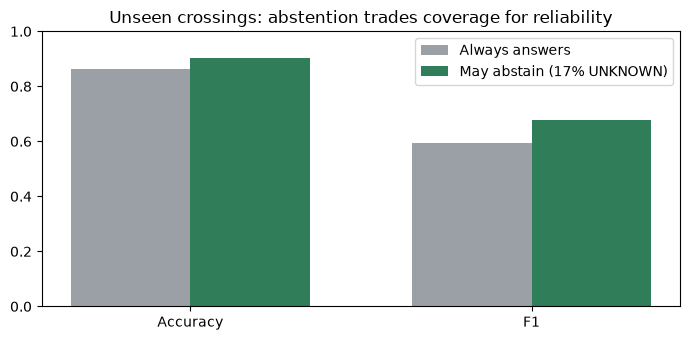

In [5]:
import matplotlib.pyplot as plt
abst = report['classifier']['abstention']
seen_a = abst['seen_crossing_test']
unseen_a = abst['unseen_crossing_test']
print('unknown_band:', seen_a['unknown_band'])
for name, block, plain in [('seen', seen_a, seen), ('unseen', unseen_a, unseen)]:
    print(f"{name:>7}: abstain={block['unknown_rate']:.1%}  decided_accuracy={block['decided_accuracy']:.3f} (vs {plain['accuracy']:.3f})  decided_f1={block['decided_f1']:.3f} (vs {plain['f1']:.3f})")

labels = ['Accuracy', 'F1']
fig, ax = plt.subplots(figsize=(7, 3.5))
x = range(len(labels))
width = 0.35
always = [unseen['accuracy'], unseen['f1']]
decided = [unseen_a['decided_accuracy'], unseen_a['decided_f1']]
ax.bar([i - width/2 for i in x], always, width, label='Always answers', color='#9aa0a6')
ax.bar([i + width/2 for i in x], decided, width, label=f"May abstain ({unseen_a['unknown_rate']:.0%} UNKNOWN)", color='#2f7d59')
ax.set_xticks(list(x), labels)
ax.set_ylim(0, 1)
ax.set_title('Unseen crossings: abstention trades coverage for reliability')
ax.legend()
plt.tight_layout()
plt.show()

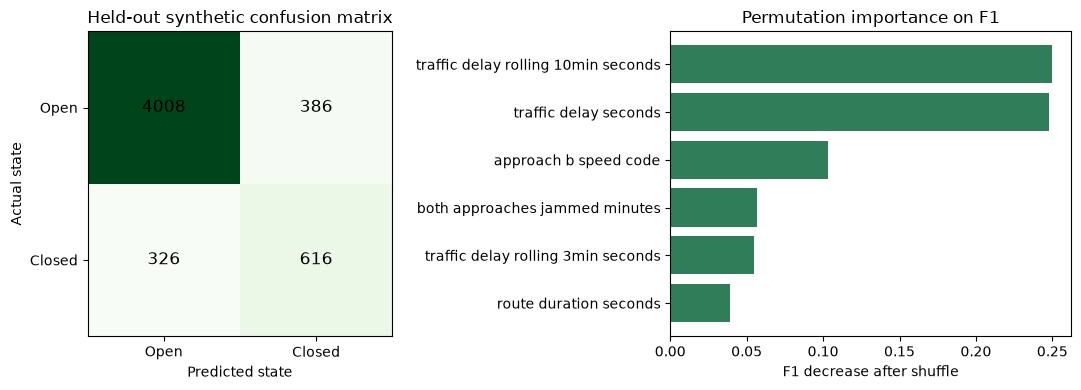

In [6]:
matrix = np.array(report['classifier']['test_metrics']['confusion_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(matrix, cmap='Greens')
axes[0].set_title('Held-out synthetic confusion matrix')
axes[0].set_xlabel('Predicted state')
axes[0].set_ylabel('Actual state')
axes[0].set_xticks([0, 1], ['Open', 'Closed'])
axes[0].set_yticks([0, 1], ['Open', 'Closed'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, matrix[i, j], ha='center', va='center', fontsize=12)

features = report['classifier']['top_permutation_features'][:6]
names = [item[0].replace('_', ' ') for item in features][::-1]
values = [item[1] for item in features][::-1]
axes[1].barh(names, values, color='#2f7d59')
axes[1].set_title('Permutation importance on F1')
axes[1].set_xlabel('F1 decrease after shuffle')
plt.tight_layout()
plt.show()

## Takeaways

- The classifier outperformed the transparent traffic-delay rule on both test sets, and generalized to crossings excluded from training with a modest, honestly reported F1 drop (0.634 seen vs 0.593 unseen).
- Abstaining with UNKNOWN on the least confident 17% of unseen-crossing rows raised decided-row accuracy to 90.3% — the model knows when it does not know.
- Reopening-time MAE was **1.64 minutes** in this simulator.
- The current evidence is suitable for demonstrating architecture and reproducibility, not claiming production accuracy.
- The next validation step is to record independent real crossing events and report synthetic and real metrics separately.

**Data source:** `data/synthetic/crossing_observations.csv`
**Evaluation artifact:** `artifacts/model_evaluation.json`